# Dense, CNN, RNN, LSTM, and GRU Forecasting

## 1. Position in the Learning Progression

The previous **Time Series Foundations** folder established:

```text
temporal structure
→ leakage-free splitting
→ scaling
→ windowing
→ baselines
→ forecasting metrics
```

This notebook now asks:

> How do different neural-network architectures use the same historical window to forecast the future?

The focus is a **controlled architecture comparison**, not simply training one LSTM.

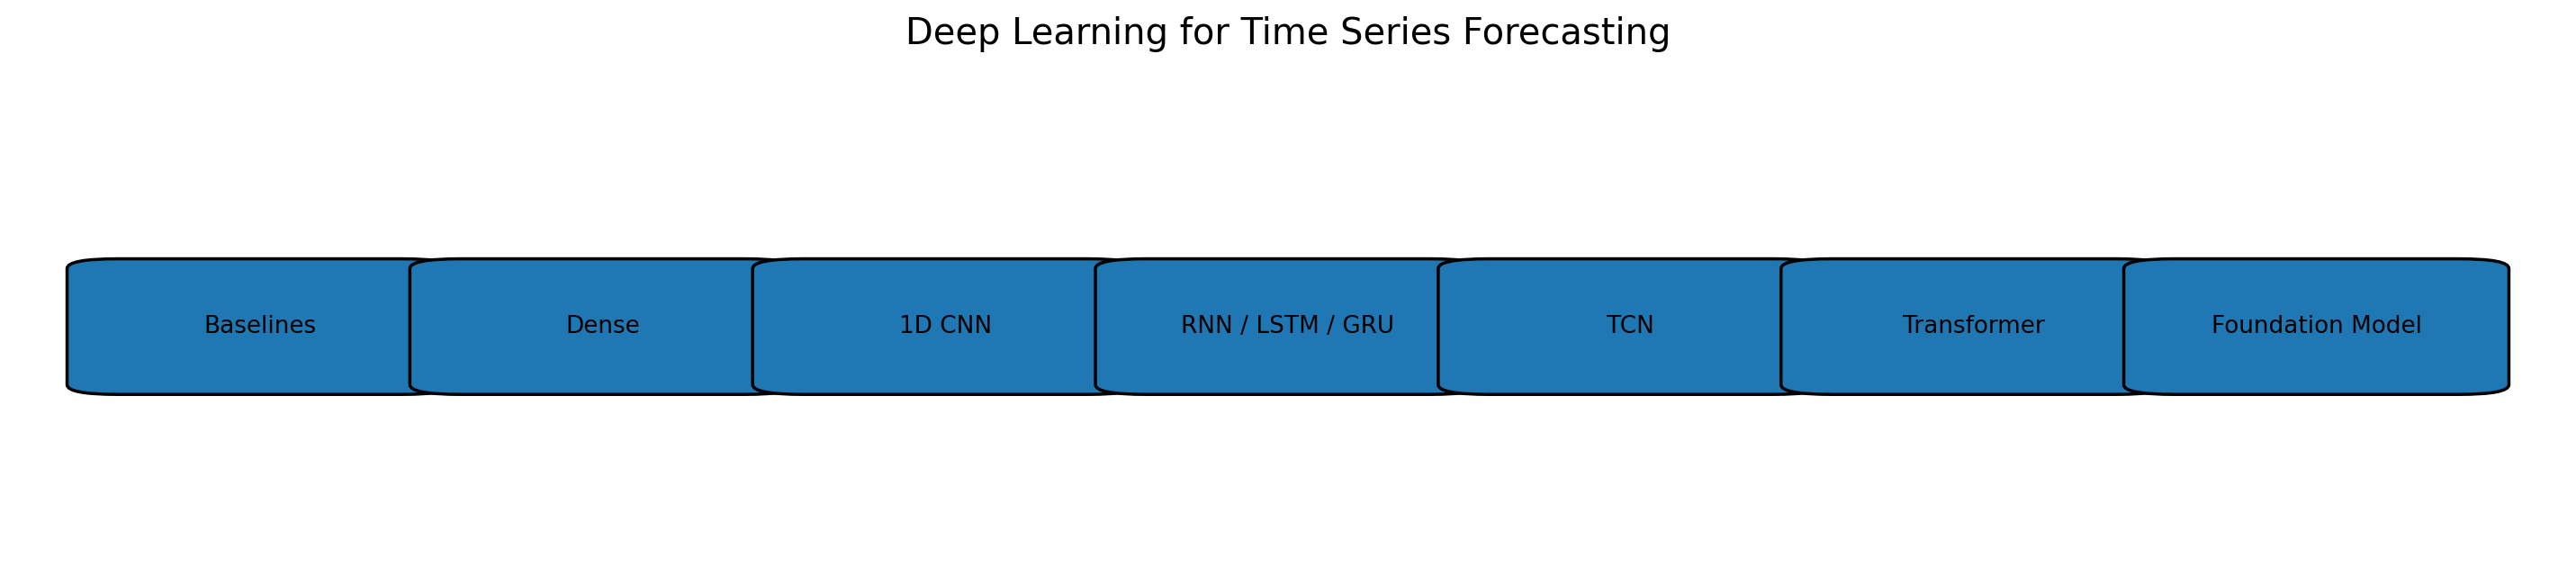

## 2. Learning Objectives

By the end of this notebook, you should be able to:

- explain how Dense, CNN, RNN, LSTM, and GRU models see the same forecasting window differently,
- construct a leakage-free train/validation/test pipeline,
- build a seasonal-naive benchmark,
- create model-ready temporal tensors,
- build each neural architecture explicitly with PyTorch,
- inspect parameter counts and tensor shapes,
- train models under a common experimental setup,
- convert scaled predictions back to original units,
- calculate MAE and RMSE,
- compare models fairly,
- inspect learning curves and forecast plots,
- explain why a more complex sequence model does not automatically outperform a simpler model.

## 3. How Different Neural Networks See Time

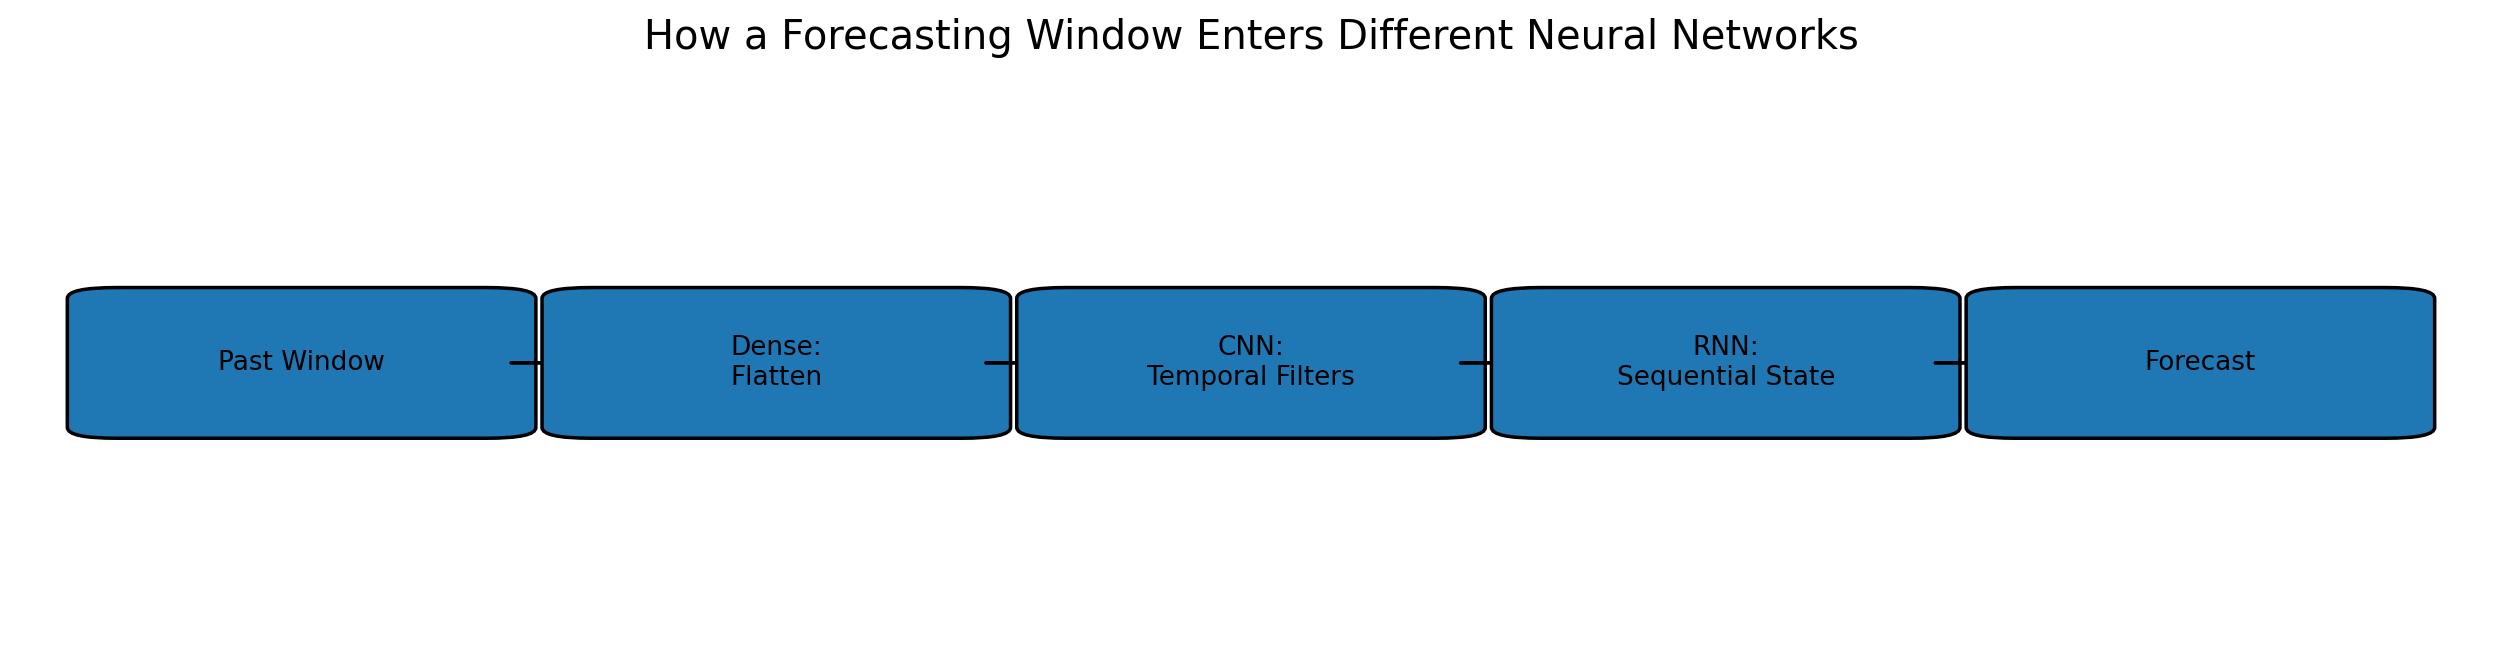

The same lookback window can be processed in several ways.

### Dense Network

Treats the window as one fixed vector.

### 1D CNN

Searches for local temporal patterns with filters.

### RNN

Processes timesteps sequentially while carrying a hidden state.

### LSTM

Adds memory gates designed to preserve useful information over longer dependencies.

### GRU

Uses a simpler gated recurrent structure than LSTM.

## 4. Controlled Experiment Design

All models should use the same:

```text
dataset
train period
validation period
test period
lookback
forecast horizon
target scaling
training epochs
evaluation metrics
```

Otherwise, differences in performance cannot be attributed fairly to architecture.

## 5. Imports and Reproducibility

In [18]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

np.random.seed(42)

torch.manual_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:")
print(device)

Device:
cpu


## 6. Load the Hourly Demand Dataset

In [19]:
"""data_path = "data/synthetic_hourly_demand.csv"

data = pd.read_csv(
    data_path
)

data["timestamp"] = pd.to_datetime(
    data["timestamp"]
)

data = data.set_index(
    "timestamp"
)

print("Dataset shape:")
print(data.shape)

print()

print(data.head())"""

'data_path = "data/synthetic_hourly_demand.csv"\n\ndata = pd.read_csv(\n    data_path\n)\n\ndata["timestamp"] = pd.to_datetime(\n    data["timestamp"]\n)\n\ndata = data.set_index(\n    "timestamp"\n)\n\nprint("Dataset shape:")\nprint(data.shape)\n\nprint()\n\nprint(data.head())'

In [20]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

data = pd.read_csv(file_name)

data["timestamp"] = pd.to_datetime(data["timestamp"])

data = data.set_index("timestamp")

print("Dataset shape:")
print(data.shape)

print()

print(data.head())

Saving synthetic_hourly_demand.csv to synthetic_hourly_demand (1).csv
Dataset shape:
(4320, 3)

                        demand  temperature   humidity
timestamp                                             
2024-01-01 00:00:00  57.677652    14.245071  68.643648
2024-01-01 01:00:00  55.247391    13.548160  67.526067
2024-01-01 02:00:00  60.693636    15.476342  69.414668
2024-01-01 03:00:00  59.486114    17.981244  61.808302
2024-01-01 04:00:00  61.259739    16.898770  60.423073


## 7. Inspect the Forecast Target

The target is hourly `demand`.

This first notebook is **univariate**:

```text
Past demand values
        ↓
Predict next demand value
```

Multivariate and multi-step forecasting are handled later.

In [21]:
target = data[
    "demand"
].copy()

print("Target length:")
print(len(target))

print()

print("Target minimum:")
print(target.min())

print()

print("Target maximum:")
print(target.max())

Target length:
4320

Target minimum:
38.62015742566125

Target maximum:
82.01455520995061


## 8. Chronological Train, Validation, and Test Split

We preserve time order:

```text
70% train
15% validation
15% test
```

In [22]:
number_of_rows = len(
    target
)

train_end = int(
    number_of_rows * 0.70
)

validation_end = int(
    number_of_rows * 0.85
)

train_series = target.iloc[
    :train_end
].copy()

validation_series = target.iloc[
    train_end:validation_end
].copy()

test_series = target.iloc[
    validation_end:
].copy()

print("Training rows:")
print(len(train_series))

print()

print("Validation rows:")
print(len(validation_series))

print()

print("Test rows:")
print(len(test_series))

Training rows:
3024

Validation rows:
648

Test rows:
648


## 9. Scale Using Training Statistics Only

The mean and standard deviation are learned from the training period.

The validation and test periods reuse those same values.

In [23]:
train_mean = train_series.mean()

train_std = train_series.std()

print("Training mean:")
print(train_mean)

print()

print("Training standard deviation:")
print(train_std)

Training mean:
58.131815796315834

Training standard deviation:
7.436389347851541


In [24]:
train_scaled = (
    train_series - train_mean
) / train_std

validation_scaled = (
    validation_series - train_mean
) / train_std

test_scaled = (
    test_series - train_mean
) / train_std

print("Scaled training mean:")
print(train_scaled.mean())

print()

print("Scaled training standard deviation:")
print(train_scaled.std())

Scaled training mean:
1.5037941497568257e-16

Scaled training standard deviation:
0.9999999999999997


## 10. Define the Forecasting Problem

Use:

```text
lookback = 24 hours
horizon = 1 hour
```

So every model receives the previous 24 demand values and predicts the next demand value.

In [25]:
lookback = 24

forecast_horizon = 1

print("Lookback:")
print(lookback)

print()

print("Forecast horizon:")
print(forecast_horizon)

Lookback:
24

Forecast horizon:
1


## 11. Build Windows Explicitly

The windowing mechanism was developed in the previous folder.

Here we use a reusable function while still keeping the alignment visible.

In [26]:
def create_windows(
    values,
    lookback
):

    X = []

    y = []

    for start_index in range(
        0,
        len(values) - lookback
    ):

        end_index = (
            start_index + lookback
        )

        input_window = values[
            start_index:end_index
        ]

        target_value = values[
            end_index
        ]

        X.append(
            input_window
        )

        y.append(
            target_value
        )

    X = np.array(
        X,
        dtype=np.float32
    )

    y = np.array(
        y,
        dtype=np.float32
    )

    return X, y

In [27]:
X_train, y_train = create_windows(
    train_scaled.to_numpy(),
    lookback
)

X_validation, y_validation = create_windows(
    validation_scaled.to_numpy(),
    lookback
)

X_test, y_test = create_windows(
    test_scaled.to_numpy(),
    lookback
)

print("Training X shape:")
print(X_train.shape)

print()

print("Training y shape:")
print(y_train.shape)

Training X shape:
(3000, 24)

Training y shape:
(3000,)


## 12. Inspect One Forecasting Example

In [28]:
example_index = 0

print("Input window:")
print(
    X_train[
        example_index
    ]
)

print()

print("Target:")
print(
    y_train[
        example_index
    ]
)

Input window:
[-0.06107312 -0.38787982  0.34449786  0.18211772  0.4206239  -0.10528501
 -0.33201584  0.16540952  0.20376197 -0.47954935 -0.65139455 -0.51123536
 -0.78821355 -1.1107622  -1.0756118  -1.8354906  -1.6896619  -1.198121
 -1.530453   -1.3185933  -0.6719992  -1.3333126  -0.44332975  0.16076116]

Target:
-0.15431567


## 13. Create a Seasonal-Naive Benchmark

For hourly data with daily seasonality, a strong simple benchmark is:

$$
\hat{y}_t = y_{t-24}
$$

Because our lookback is 24, the first value in each test window is exactly the value from one day earlier.

In [29]:
seasonal_naive_scaled = X_test[
    :,
    0
]

print("Seasonal naive prediction shape:")
print(
    seasonal_naive_scaled.shape
)

Seasonal naive prediction shape:
(624,)


## 14. Convert Scaled Values Back to Original Units

In [30]:
def inverse_scale(
    scaled_values
):

    original_values = (
        scaled_values
        * train_std
        + train_mean
    )

    return original_values

In [31]:
actual_test = inverse_scale(
    y_test
)

seasonal_naive_predictions = inverse_scale(
    seasonal_naive_scaled
)

print("First five actual values:")
print(
    actual_test[
        :5
    ]
)

print()

print("First five seasonal-naive predictions:")
print(
    seasonal_naive_predictions[
        :5
    ]
)

First five actual values:
[68.97793854 72.43970001 74.16208542 75.83416832 74.0239724 ]

First five seasonal-naive predictions:
[65.61403311 65.79686821 69.55114544 73.46395577 76.20149315]


## 15. Evaluation Metrics

We use MAE and RMSE throughout this notebook.

### MAE

Measures typical absolute error.

### RMSE

Penalizes larger errors more strongly.

In [32]:
def calculate_mae(
    actual,
    predicted
):

    absolute_errors = np.abs(
        actual - predicted
    )

    mae = np.mean(
        absolute_errors
    )

    return mae


def calculate_rmse(
    actual,
    predicted
):

    squared_errors = (
        actual - predicted
    ) ** 2

    mse = np.mean(
        squared_errors
    )

    rmse = np.sqrt(
        mse
    )

    return rmse

In [33]:
seasonal_naive_mae = calculate_mae(
    actual_test,
    seasonal_naive_predictions
)

seasonal_naive_rmse = calculate_rmse(
    actual_test,
    seasonal_naive_predictions
)

print("Seasonal-naive MAE:")
print(
    seasonal_naive_mae
)

print()

print("Seasonal-naive RMSE:")
print(
    seasonal_naive_rmse
)

Seasonal-naive MAE:
2.8140546628871026

Seasonal-naive RMSE:
3.48392405958997


## 16. Prepare PyTorch Tensors

Sequence models expect:

```text
(samples, timesteps, features)
```

Because this experiment is univariate:

```text
features = 1
```

In [34]:
X_train_tensor = torch.tensor(
    X_train
)

X_validation_tensor = torch.tensor(
    X_validation
)

X_test_tensor = torch.tensor(
    X_test
)

y_train_tensor = torch.tensor(
    y_train
).unsqueeze(
    1
)

y_validation_tensor = torch.tensor(
    y_validation
).unsqueeze(
    1
)

y_test_tensor = torch.tensor(
    y_test
).unsqueeze(
    1
)

print("Before feature dimension:")
print(
    X_train_tensor.shape
)

Before feature dimension:
torch.Size([3000, 24])


In [35]:
X_train_sequence = X_train_tensor.unsqueeze(
    2
)

X_validation_sequence = X_validation_tensor.unsqueeze(
    2
)

X_test_sequence = X_test_tensor.unsqueeze(
    2
)

print("Sequence training shape:")
print(
    X_train_sequence.shape
)

Sequence training shape:
torch.Size([3000, 24, 1])


## 17. Create DataLoaders

In [36]:
batch_size = 64

train_dataset = TensorDataset(
    X_train_sequence,
    y_train_tensor
)

validation_dataset = TensorDataset(
    X_validation_sequence,
    y_validation_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:")
print(
    len(
        train_loader
    )
)

Training batches:
47


# Part I — Dense Neural Network

## 18. Dense Forecasting Idea

A Dense network does not explicitly preserve sequential recurrence.

The 24-hour window is flattened into:

```text
[x(t-23), ..., x(t)]
```

and treated as one vector.

This makes the Dense model a useful neural baseline.

In [37]:
class DenseForecaster(
    nn.Module
):

    def __init__(
        self,
        lookback
    ):
        super().__init__()

        self.layer_1 = nn.Linear(
            lookback,
            64
        )

        self.layer_2 = nn.Linear(
            64,
            32
        )

        self.output_layer = nn.Linear(
            32,
            1
        )

        self.activation = nn.ReLU()


    def forward(
        self,
        x
    ):

        x = x.squeeze(
            2
        )

        x = self.layer_1(
            x
        )

        x = self.activation(
            x
        )

        x = self.layer_2(
            x
        )

        x = self.activation(
            x
        )

        prediction = self.output_layer(
            x
        )

        return prediction

## 19. Inspect One Dense Forward Pass

In [38]:
dense_model = DenseForecaster(
    lookback=lookback
)

dense_model = dense_model.to(
    device
)

example_batch = X_train_sequence[
    :8
].to(
    device
)

with torch.no_grad():

    example_prediction = dense_model(
        example_batch
    )

print("Input shape:")
print(
    example_batch.shape
)

print()

print("Prediction shape:")
print(
    example_prediction.shape
)

Input shape:
torch.Size([8, 24, 1])

Prediction shape:
torch.Size([8, 1])


# Part II — 1D Convolutional Neural Network

## 20. Why a CNN Can Forecast Time Series

A 1D convolution moves a temporal filter across the sequence.

Instead of looking for spatial image patterns, it learns local temporal motifs such as:

```text
rise → peak → decline
```

or repeating local structures.

In [39]:
class CNN1DForecaster(
    nn.Module
):

    def __init__(
        self,
        lookback
    ):
        super().__init__()

        self.conv_1 = nn.Conv1d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.conv_2 = nn.Conv1d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.activation = nn.ReLU()

        self.flatten = nn.Flatten()

        self.output_layer = nn.Linear(
            32 * lookback,
            1
        )


    def forward(
        self,
        x
    ):

        x = x.transpose(
            1,
            2
        )

        x = self.conv_1(
            x
        )

        x = self.activation(
            x
        )

        x = self.conv_2(
            x
        )

        x = self.activation(
            x
        )

        x = self.flatten(
            x
        )

        prediction = self.output_layer(
            x
        )

        return prediction

## 21. Inspect CNN Tensor Shapes

In [40]:
cnn_model = CNN1DForecaster(
    lookback=lookback
)

cnn_model = cnn_model.to(
    device
)

with torch.no_grad():

    cnn_prediction = cnn_model(
        example_batch
    )

print("Sequence input shape:")
print(
    example_batch.shape
)

print()

print("CNN prediction shape:")
print(
    cnn_prediction.shape
)

Sequence input shape:
torch.Size([8, 24, 1])

CNN prediction shape:
torch.Size([8, 1])


# Part III — Simple RNN

## 22. RNN Forecasting Idea

The RNN updates a hidden state while reading the sequence:

$$
h_t = f(x_t, h_{t-1})
$$

The final hidden state becomes a compressed summary of the historical window.

In [41]:
class RNNForecaster(
    nn.Module
):

    def __init__(
        self,
        hidden_size=32
    ):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.output_layer = nn.Linear(
            hidden_size,
            1
        )


    def forward(
        self,
        x
    ):

        output_sequence, hidden_state = self.rnn(
            x
        )

        final_hidden = hidden_state[
            -1
        ]

        prediction = self.output_layer(
            final_hidden
        )

        return prediction

# Part IV — LSTM

## 23. Why LSTM

An LSTM introduces gated memory.

The detailed gate equations were covered in the earlier **Sequence Modeling** section.

Here the question is practical:

> Does gated memory improve forecasting relative to simpler architectures on the same temporal problem?

In [42]:
class LSTMForecaster(
    nn.Module
):

    def __init__(
        self,
        hidden_size=32
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.output_layer = nn.Linear(
            hidden_size,
            1
        )


    def forward(
        self,
        x
    ):

        output_sequence, states = self.lstm(
            x
        )

        hidden_state = states[
            0
        ]

        final_hidden = hidden_state[
            -1
        ]

        prediction = self.output_layer(
            final_hidden
        )

        return prediction

# Part V — GRU

## 24. Why GRU

A GRU is also gated but uses a simpler recurrent structure than LSTM.

This often means fewer parameters while still modeling longer dependencies better than a basic RNN.

In [43]:
class GRUForecaster(
    nn.Module
):

    def __init__(
        self,
        hidden_size=32
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=1,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.output_layer = nn.Linear(
            hidden_size,
            1
        )


    def forward(
        self,
        x
    ):

        output_sequence, hidden_state = self.gru(
            x
        )

        final_hidden = hidden_state[
            -1
        ]

        prediction = self.output_layer(
            final_hidden
        )

        return prediction

## 25. Parameter Count

Parameter count is one part of model complexity.

A larger model is not automatically better.

In [44]:
def count_parameters(
    model
):

    total = 0

    for parameter in model.parameters():

        total = (
            total
            + parameter.numel()
        )

    return total

In [45]:
models_for_count = {
    "Dense": DenseForecaster(
        lookback
    ),
    "1D CNN": CNN1DForecaster(
        lookback
    ),
    "RNN": RNNForecaster(),
    "LSTM": LSTMForecaster(),
    "GRU": GRUForecaster()
}

for name, model in models_for_count.items():

    print(
        name,
        "parameters:",
        count_parameters(
            model
        )
    )

Dense parameters: 3713
1D CNN parameters: 2401
RNN parameters: 1153
LSTM parameters: 4513
GRU parameters: 3393


## 26. Training Function

The architecture has now been made explicit.

We can use one common training function so every model is optimized under the same procedure.

In [46]:
def train_forecasting_model(
    model,
    train_loader,
    validation_loader,
    number_of_epochs=20,
    learning_rate=0.001
):

    model = model.to(
        device
    )

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    training_losses = []

    validation_losses = []

    start_time = time.time()

    for epoch in range(
        number_of_epochs
    ):

        model.train()

        training_loss_sum = 0.0

        training_batches = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(
                device
            )

            y_batch = y_batch.to(
                device
            )

            optimizer.zero_grad()

            predictions = model(
                X_batch
            )

            loss = criterion(
                predictions,
                y_batch
            )

            loss.backward()

            optimizer.step()

            training_loss_sum = (
                training_loss_sum
                + loss.item()
            )

            training_batches = (
                training_batches
                + 1
            )

        average_training_loss = (
            training_loss_sum
            / training_batches
        )

        model.eval()

        validation_loss_sum = 0.0

        validation_batches = 0

        with torch.no_grad():

            for X_batch, y_batch in validation_loader:

                X_batch = X_batch.to(
                    device
                )

                y_batch = y_batch.to(
                    device
                )

                predictions = model(
                    X_batch
                )

                loss = criterion(
                    predictions,
                    y_batch
                )

                validation_loss_sum = (
                    validation_loss_sum
                    + loss.item()
                )

                validation_batches = (
                    validation_batches
                    + 1
                )

        average_validation_loss = (
            validation_loss_sum
            / validation_batches
        )

        training_losses.append(
            average_training_loss
        )

        validation_losses.append(
            average_validation_loss
        )

        print(
            "Epoch:",
            epoch + 1,
            "| Train:",
            round(
                average_training_loss,
                5
            ),
            "| Validation:",
            round(
                average_validation_loss,
                5
            )
        )

    elapsed_time = (
        time.time()
        - start_time
    )

    return (
        model,
        training_losses,
        validation_losses,
        elapsed_time
    )

## 27. Train the Dense Model

In [47]:
dense_model = DenseForecaster(
    lookback
)

dense_model, dense_train_loss, dense_val_loss, dense_time = train_forecasting_model(
    dense_model,
    train_loader,
    validation_loader
)

Epoch: 1 | Train: 0.38042 | Validation: 0.12435
Epoch: 2 | Train: 0.10934 | Validation: 0.11911
Epoch: 3 | Train: 0.10355 | Validation: 0.11111
Epoch: 4 | Train: 0.10014 | Validation: 0.11065
Epoch: 5 | Train: 0.09804 | Validation: 0.11459
Epoch: 6 | Train: 0.0971 | Validation: 0.10513
Epoch: 7 | Train: 0.09627 | Validation: 0.10466
Epoch: 8 | Train: 0.09431 | Validation: 0.10578
Epoch: 9 | Train: 0.09357 | Validation: 0.10407
Epoch: 10 | Train: 0.09309 | Validation: 0.10557
Epoch: 11 | Train: 0.0924 | Validation: 0.10396
Epoch: 12 | Train: 0.09225 | Validation: 0.11242
Epoch: 13 | Train: 0.09156 | Validation: 0.10454
Epoch: 14 | Train: 0.09082 | Validation: 0.10129
Epoch: 15 | Train: 0.09117 | Validation: 0.10482
Epoch: 16 | Train: 0.09144 | Validation: 0.10168
Epoch: 17 | Train: 0.09007 | Validation: 0.11519
Epoch: 18 | Train: 0.09049 | Validation: 0.10593
Epoch: 19 | Train: 0.09043 | Validation: 0.11803
Epoch: 20 | Train: 0.08912 | Validation: 0.10772


## 28. Train the 1D CNN

In [48]:
cnn_model = CNN1DForecaster(
    lookback
)

cnn_model, cnn_train_loss, cnn_val_loss, cnn_time = train_forecasting_model(
    cnn_model,
    train_loader,
    validation_loader
)

Epoch: 1 | Train: 0.29644 | Validation: 0.14397
Epoch: 2 | Train: 0.10619 | Validation: 0.10342
Epoch: 3 | Train: 0.10221 | Validation: 0.10255
Epoch: 4 | Train: 0.09952 | Validation: 0.09967
Epoch: 5 | Train: 0.09843 | Validation: 0.09922
Epoch: 6 | Train: 0.09608 | Validation: 0.10029
Epoch: 7 | Train: 0.09438 | Validation: 0.1014
Epoch: 8 | Train: 0.09455 | Validation: 0.09976
Epoch: 9 | Train: 0.09329 | Validation: 0.10022
Epoch: 10 | Train: 0.09513 | Validation: 0.10855
Epoch: 11 | Train: 0.09539 | Validation: 0.10077
Epoch: 12 | Train: 0.09282 | Validation: 0.10601
Epoch: 13 | Train: 0.09232 | Validation: 0.10973
Epoch: 14 | Train: 0.09581 | Validation: 0.09988
Epoch: 15 | Train: 0.09083 | Validation: 0.10046
Epoch: 16 | Train: 0.09219 | Validation: 0.10071
Epoch: 17 | Train: 0.09141 | Validation: 0.1024
Epoch: 18 | Train: 0.09152 | Validation: 0.10111
Epoch: 19 | Train: 0.09201 | Validation: 0.10955
Epoch: 20 | Train: 0.09179 | Validation: 0.10528


## 29. Train the RNN

In [49]:
rnn_model = RNNForecaster()

rnn_model, rnn_train_loss, rnn_val_loss, rnn_time = train_forecasting_model(
    rnn_model,
    train_loader,
    validation_loader
)

Epoch: 1 | Train: 0.33131 | Validation: 0.20554
Epoch: 2 | Train: 0.14073 | Validation: 0.19516
Epoch: 3 | Train: 0.13489 | Validation: 0.19225
Epoch: 4 | Train: 0.13377 | Validation: 0.18564
Epoch: 5 | Train: 0.12998 | Validation: 0.20181
Epoch: 6 | Train: 0.12747 | Validation: 0.17735
Epoch: 7 | Train: 0.1219 | Validation: 0.16075
Epoch: 8 | Train: 0.10895 | Validation: 0.12285
Epoch: 9 | Train: 0.10422 | Validation: 0.12233
Epoch: 10 | Train: 0.10175 | Validation: 0.12671
Epoch: 11 | Train: 0.10094 | Validation: 0.13306
Epoch: 12 | Train: 0.09864 | Validation: 0.11982
Epoch: 13 | Train: 0.09928 | Validation: 0.1178
Epoch: 14 | Train: 0.10035 | Validation: 0.12139
Epoch: 15 | Train: 0.09967 | Validation: 0.12023
Epoch: 16 | Train: 0.09694 | Validation: 0.12239
Epoch: 17 | Train: 0.09642 | Validation: 0.12279
Epoch: 18 | Train: 0.09505 | Validation: 0.11547
Epoch: 19 | Train: 0.09692 | Validation: 0.12123
Epoch: 20 | Train: 0.09511 | Validation: 0.11269


## 30. Train the LSTM

In [50]:
lstm_model = LSTMForecaster()

lstm_model, lstm_train_loss, lstm_val_loss, lstm_time = train_forecasting_model(
    lstm_model,
    train_loader,
    validation_loader
)

Epoch: 1 | Train: 0.76653 | Validation: 0.91983
Epoch: 2 | Train: 0.30052 | Validation: 0.25502
Epoch: 3 | Train: 0.12836 | Validation: 0.16382
Epoch: 4 | Train: 0.10993 | Validation: 0.13401
Epoch: 5 | Train: 0.10069 | Validation: 0.12304
Epoch: 6 | Train: 0.09808 | Validation: 0.11767
Epoch: 7 | Train: 0.09553 | Validation: 0.11028
Epoch: 8 | Train: 0.09519 | Validation: 0.10506
Epoch: 9 | Train: 0.09424 | Validation: 0.11885
Epoch: 10 | Train: 0.09378 | Validation: 0.10589
Epoch: 11 | Train: 0.09341 | Validation: 0.10877
Epoch: 12 | Train: 0.09415 | Validation: 0.10299
Epoch: 13 | Train: 0.09414 | Validation: 0.11407
Epoch: 14 | Train: 0.09326 | Validation: 0.10112
Epoch: 15 | Train: 0.09309 | Validation: 0.10618
Epoch: 16 | Train: 0.0928 | Validation: 0.10159
Epoch: 17 | Train: 0.09258 | Validation: 0.1162
Epoch: 18 | Train: 0.09318 | Validation: 0.10082
Epoch: 19 | Train: 0.09278 | Validation: 0.10576
Epoch: 20 | Train: 0.09272 | Validation: 0.11059


## 31. Train the GRU

In [51]:
gru_model = GRUForecaster()

gru_model, gru_train_loss, gru_val_loss, gru_time = train_forecasting_model(
    gru_model,
    train_loader,
    validation_loader
)

Epoch: 1 | Train: 0.70816 | Validation: 0.63817
Epoch: 2 | Train: 0.28257 | Validation: 0.21011
Epoch: 3 | Train: 0.13649 | Validation: 0.19155
Epoch: 4 | Train: 0.13144 | Validation: 0.19844
Epoch: 5 | Train: 0.12902 | Validation: 0.18027
Epoch: 6 | Train: 0.12638 | Validation: 0.17336
Epoch: 7 | Train: 0.12185 | Validation: 0.15433
Epoch: 8 | Train: 0.11395 | Validation: 0.13576
Epoch: 9 | Train: 0.10756 | Validation: 0.1199
Epoch: 10 | Train: 0.10089 | Validation: 0.10757
Epoch: 11 | Train: 0.09964 | Validation: 0.10919
Epoch: 12 | Train: 0.09745 | Validation: 0.11698
Epoch: 13 | Train: 0.09669 | Validation: 0.10932
Epoch: 14 | Train: 0.09543 | Validation: 0.11335
Epoch: 15 | Train: 0.09495 | Validation: 0.10924
Epoch: 16 | Train: 0.09573 | Validation: 0.10741
Epoch: 17 | Train: 0.09519 | Validation: 0.10585
Epoch: 18 | Train: 0.09447 | Validation: 0.10453
Epoch: 19 | Train: 0.09441 | Validation: 0.109
Epoch: 20 | Train: 0.0944 | Validation: 0.10554


## 32. Plot Learning Curves

Training loss measures fit to the training windows.

Validation loss gives a better indication of generalization to later unseen time.

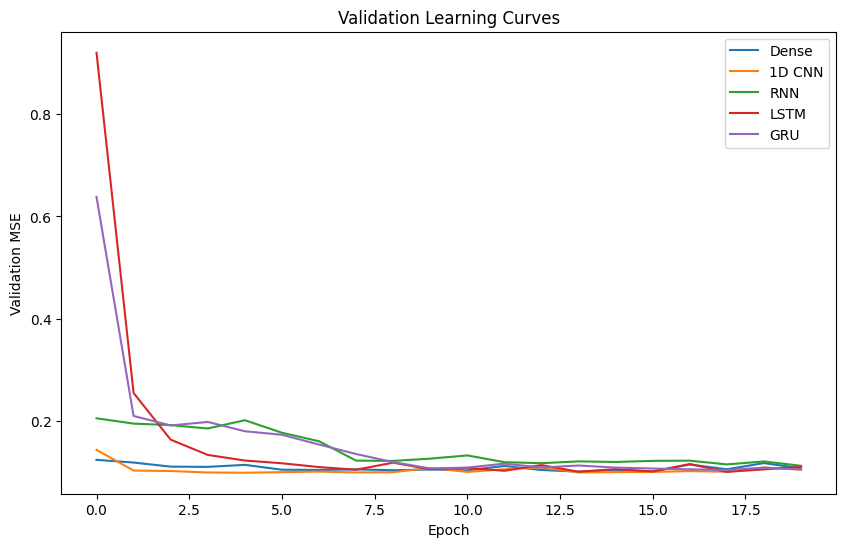

In [52]:
plt.figure(figsize=(10, 6))

plt.plot(
    dense_val_loss,
    label="Dense"
)

plt.plot(
    cnn_val_loss,
    label="1D CNN"
)

plt.plot(
    rnn_val_loss,
    label="RNN"
)

plt.plot(
    lstm_val_loss,
    label="LSTM"
)

plt.plot(
    gru_val_loss,
    label="GRU"
)

plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Validation Learning Curves")
plt.legend()

plt.show()

## 33. Prediction Function

In [53]:
def predict_scaled(
    model,
    X_tensor
):

    model.eval()

    X_tensor = X_tensor.to(
        device
    )

    with torch.no_grad():

        predictions = model(
            X_tensor
        )

    predictions = predictions.squeeze(
        1
    )

    predictions = predictions.cpu().numpy()

    return predictions

## 34. Generate Test Predictions

In [54]:
dense_scaled_predictions = predict_scaled(
    dense_model,
    X_test_sequence
)

cnn_scaled_predictions = predict_scaled(
    cnn_model,
    X_test_sequence
)

rnn_scaled_predictions = predict_scaled(
    rnn_model,
    X_test_sequence
)

lstm_scaled_predictions = predict_scaled(
    lstm_model,
    X_test_sequence
)

gru_scaled_predictions = predict_scaled(
    gru_model,
    X_test_sequence
)

## 35. Inverse Transform Predictions

In [55]:
dense_predictions = inverse_scale(
    dense_scaled_predictions
)

cnn_predictions = inverse_scale(
    cnn_scaled_predictions
)

rnn_predictions = inverse_scale(
    rnn_scaled_predictions
)

lstm_predictions = inverse_scale(
    lstm_scaled_predictions
)

gru_predictions = inverse_scale(
    gru_scaled_predictions
)

## 36. Build the Comparison Table

In [56]:
comparison_rows = []

comparison_rows.append(
    {
        "Model": "Seasonal Naive",
        "MAE": calculate_mae(
            actual_test,
            seasonal_naive_predictions
        ),
        "RMSE": calculate_rmse(
            actual_test,
            seasonal_naive_predictions
        ),
        "Parameters": 0,
        "Training Time": 0.0
    }
)

trained_models = [
    (
        "Dense",
        dense_model,
        dense_predictions,
        dense_time
    ),
    (
        "1D CNN",
        cnn_model,
        cnn_predictions,
        cnn_time
    ),
    (
        "RNN",
        rnn_model,
        rnn_predictions,
        rnn_time
    ),
    (
        "LSTM",
        lstm_model,
        lstm_predictions,
        lstm_time
    ),
    (
        "GRU",
        gru_model,
        gru_predictions,
        gru_time
    )
]

for (
    name,
    model,
    predictions,
    training_time
) in trained_models:

    comparison_rows.append(
        {
            "Model": name,
            "MAE": calculate_mae(
                actual_test,
                predictions
            ),
            "RMSE": calculate_rmse(
                actual_test,
                predictions
            ),
            "Parameters": count_parameters(
                model
            ),
            "Training Time": training_time
        }
    )

comparison_table = pd.DataFrame(
    comparison_rows
)

comparison_table = comparison_table.sort_values(
    by="MAE"
)

print(
    comparison_table
)

            Model       MAE      RMSE  Parameters  Training Time
2          1D CNN  1.896705  2.391079        2401       3.277617
1           Dense  2.020991  2.508822        3713       1.891418
5             GRU  2.203714  2.720325        3393      13.458530
4            LSTM  2.280803  2.800297        4513       7.738521
3             RNN  2.430203  2.993028        1153       4.630355
0  Seasonal Naive  2.814055  3.483924           0       0.000000


## 37. Visualize Forecasts on the Same Test Segment

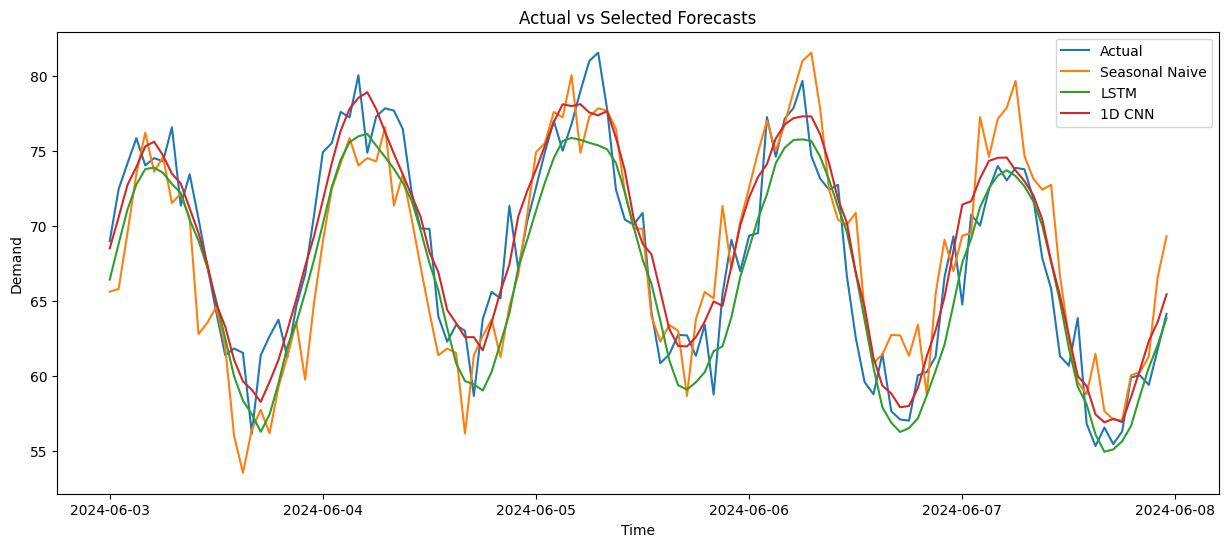

In [57]:
plot_length = 24 * 5

test_timestamps = test_series.index[
    lookback:
]

plt.figure(figsize=(15, 6))

plt.plot(
    test_timestamps[
        :plot_length
    ],
    actual_test[
        :plot_length
    ],
    label="Actual"
)

plt.plot(
    test_timestamps[
        :plot_length
    ],
    seasonal_naive_predictions[
        :plot_length
    ],
    label="Seasonal Naive"
)

plt.plot(
    test_timestamps[
        :plot_length
    ],
    lstm_predictions[
        :plot_length
    ],
    label="LSTM"
)

plt.plot(
    test_timestamps[
        :plot_length
    ],
    cnn_predictions[
        :plot_length
    ],
    label="1D CNN"
)

plt.xlabel("Time")
plt.ylabel("Demand")
plt.title("Actual vs Selected Forecasts")
plt.legend()

plt.show()

## 38. Residual Comparison

In [58]:
lstm_residuals = (
    actual_test
    - lstm_predictions
)

cnn_residuals = (
    actual_test
    - cnn_predictions
)

print("LSTM residual mean:")
print(
    lstm_residuals.mean()
)

print()

print("CNN residual mean:")
print(
    cnn_residuals.mean()
)

LSTM residual mean:
1.3141013224902474

CNN residual mean:
-0.46654370639029924


## 39. What Should We Learn From the Comparison?

Do not interpret the table as:

> The most complex model must be the best.

Instead ask:

- Did the neural model beat seasonal naive?
- Did gating improve over the simple RNN?
- Did CNN learn the local daily pattern efficiently?
- Is the accuracy improvement worth extra parameters and training time?
- Are validation and test behavior consistent?

## 40. Limitations of This Experiment

This notebook intentionally keeps the problem controlled:

- one target variable,
- one-step forecasting,
- fixed 24-hour lookback,
- simple architectures,
- one synthetic data domain,
- no hyperparameter search,
- no probabilistic forecasting.

These limitations create the motivation for the next notebooks.

## 41. Connection to Temporal Convolutional Networks

The 1D CNN learns local temporal features, but ordinary convolution has a limited receptive field.

A **Temporal Convolutional Network (TCN)** extends convolutional forecasting using:

```text
causal convolution
+
dilation
+
residual connections
```

so long temporal contexts can be modeled efficiently.

## 42. Key Takeaways

- Different neural architectures interpret the same historical window differently.
- Dense networks provide a useful neural baseline.
- 1D CNNs learn local temporal patterns without recurrence.
- RNNs compress the sequence into recurrent hidden state.
- LSTM and GRU add gating for longer dependencies.
- Fair comparison requires identical data, windows, splits, and metrics.
- Parameter count and training time matter alongside forecast error.
- Deep learning should be compared against strong simple temporal baselines.